# 14 — PM mass mapping: MAP reconstruction of the initial conditions

A MAP reconstruction of the $\mathrm{MESH}^3$ initial-condition field on a 1LPT → spherical galaxy-overdensity mock (2 source planes, seed 0) at a **fixed cosmology** (the truth draw): the two `observable_i` maps are conditioned, the cosmology sites are pinned, and the white `initial_conditions` field is minimized by a plain **optax adam** loop with the optimizer state carried across every step. No cosmology minimization, no MCMC and no Laplace machinery — this notebook is mass mapping only. Headless: `uv run --no-sync papermill 14-PM-MassMapping.ipynb 14-PM-MassMapping.ipynb --cwd .`

Everything is saved to parquet as it is produced: the truth stages as single files in `OUT_DIR`, one IC + density-lightcone + kappa parquet per animation frame under `ic_evolution/`, `density_evolution/` and `kappa_evolution/`, the per-step loss history in `loss_history.npz` and the per-frame readout in `metrics.json`. Sections 8 onward only read those files back, so to inspect a finished run just execute sections 1–2 (imports + parameters) and then continue from section 8.

## 1. Setup

All imports live in this one cell, after the environment variables so JAX sees them before its backend initializes. The device-mesh block shards the two source planes along the N axis when more than one device is visible (SPMD M/N convention) and falls back to no sharding on a single device.

In [1]:
import os

os.environ["JAX_ENABLE_X64"] = "True"  # float32 => NaN/chaotic IC gradients
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
os.environ["HF_DATASETS_OFFLINE"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"

import json
import time
from pathlib import Path

import jax
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.pyplot as plt
import numpy as np
import optax
from numpyro.handlers import condition, seed, trace
from numpyro.infer.util import initialize_model

import jax_fli as jfli
from jax_fli.initial import interpolate_initial_conditions
from jax.sharding import AxisType, NamedSharding
from jax.sharding import PartitionSpec as P

jax.config.update("jax_enable_x64", True)

# --- device mesh: the 2 source planes sit on the N axis (SPMD M/N convention) ---
if jax.device_count() > 1:
    PDIMS = (jax.device_count(), 1)
    mesh = jax.make_mesh(PDIMS, ("x", "y"), axis_types=(AxisType.Auto, AxisType.Auto))
    sharding = NamedSharding(mesh, P("x", "y"))
else:
    PDIMS = (1, 1)
    mesh = None
    sharding = None

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## 2. Parameters and paths

All run knobs in one cell. `OUT_DIR` is the single path that points at a run: sections 3–7 write into it, sections 8+ read it back. To look at a finished run, execute this cell and section 1, then jump straight to section 8.

In [2]:
MESH = 64
NSIDE = 64
PAINT_NSIDE = 32
HALO_MULT = 1.0  # halo mass multiplier
MAP_MAX_ITER = 5000  # total optimizer steps
N_SNAPSHOTS = 50  # animation frames (frame 0 is the warm start)
KAPPA_PLOT_LIMIT = 5  # max kappa frames on the filmstrip: stride = len(kappa_snaps) // KAPPA_PLOT_LIMIT
SEED = 0
OUT_DIR = Path("results")  # parquet outputs (gitignored run-data area)

print(
    f"jax {jax.__version__}  backend {jax.default_backend()}  x64 {jax.config.jax_enable_x64}"
    f"  MESH={MESH}  devices={jax.device_count()}  sharding={'none' if sharding is None else str(sharding.spec)}"
)
print(f"OUT_DIR = {OUT_DIR.resolve()}")

jax 0.11.1  backend cpu  x64 True  MESH=64  devices=1  sharding=none
OUT_DIR = /home/wassim/Projects/NBody/jax-fli-map/docs/3-sampling-and-inference/results


## 3. Make model

1LPT → spherical galaxy-overdensity mock, two source planes at $z=0.10, 0.17$, centered observer, $z\le0.2$. The cosmology priors stay in the config (the model requires them) but the cosmology sites are conditioned in section 5, so nothing optimizes them.

In [3]:
cosmo = jc.Planck18()
box = tuple(float(x) for x in jfli.utils.compute_box_size_from_redshift(cosmo, 0.2, (0.5, 0.5, 0.5)))

priors = {
    "Omega_c": jfli.infer.PreconditionnedUniform(0.1, 0.5),
    "sigma8": jfli.infer.PreconditionnedUniform(0.6, 1.0),
}

halo_size = (int((MESH // PDIMS[0]) * HALO_MULT), int((MESH // PDIMS[1]) * HALO_MULT))

config = jfli.ppl.Configurations(
    mesh_size=(MESH, MESH, MESH),
    box_size=box,
    halo_size=halo_size,  # ghost cells for the sharded stencil/FFT exchange (~5% of the 64^3 mesh)
    field_sharding=sharding,
    sim_mode="lpt",
    nbody_solver="BullFrog",  # inert in "lpt" mode
    t0=0.001,
    t1=1.0,
    lpt_order=1,
    number_of_shells=5,
    nb_steps=5,
    paint_order="cic",
    gradient_order=4,
    laplace_fd=True,
    shell_spacing="a",
    time_stepping="D",
    min_width=1.0,
    lensing_output="density",
    map2alm_method="jax",
    min_redshift=0.001,
    max_redshift=0.2,
    n_integrate=8,
    nside=NSIDE,
    geometry="spherical",
    scheme="bilinear",
    observer_position=(0.5, 0.5, 0.5),
    paint_nside=PAINT_NSIDE,
    kernel_width_pixels=0.8,
    fiducial_cosmology=jc.Planck18,
    nz_shear=[0.10, 0.17],
    priors=priors,
    sigma_e=0.3,
    adjoint="checkpointed",
    checkpoints=2,
)
model = jfli.ppl.full_field_probmodel(config)

## 4. Trace it and show observable

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

wrote true_ic / truth_density_lightcone / truth_kappa to results
truth  Omega_c=0.1322  sigma8=0.8685   S/N per pixel ~ 22.9
truth lightcone (5, 49152)  truth kappa (2, 49152)


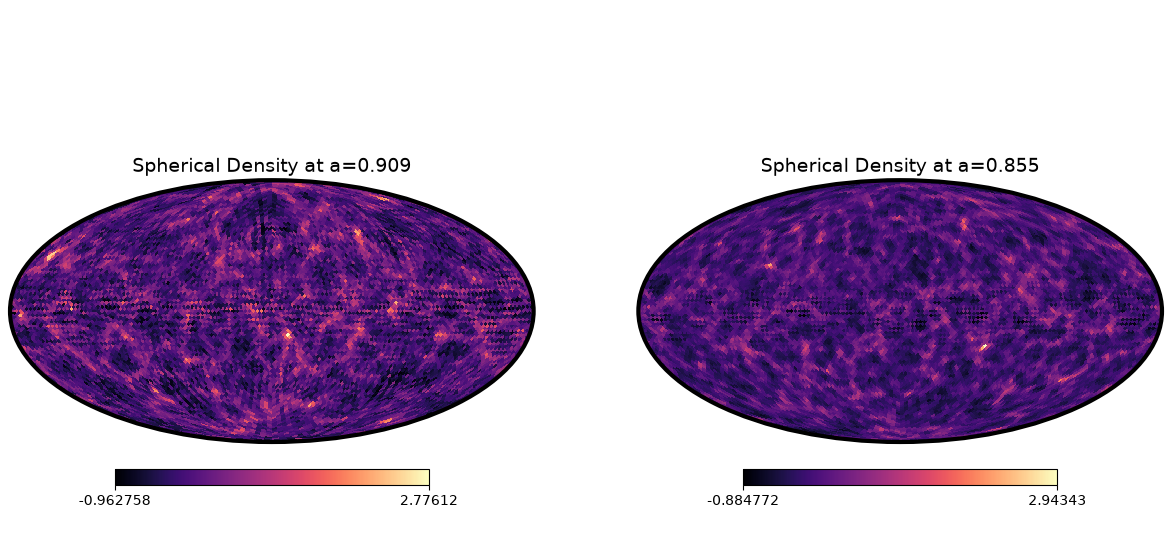

                                                                                
                                                                                
                                                                                
                                                                                
                                                                                
                                     CPU 0                                      
                                                                                
                                                                                
                                                                                
                                                                                
                                                                                

In [4]:
tr = trace(seed(model, SEED)).get_trace()

theta_truth_base = jnp.array([float(tr["Omega_c_base"]["value"]), float(tr["sigma8_base"]["value"])])
theta_truth = jnp.array([float(tr["Omega_c"]["value"]), float(tr["sigma8"]["value"])])
ic_truth_white = np.asarray(tr["initial_conditions"]["value"].array)
truth_cosmo = tr["cosmo"]["value"]

# One forward pass used for every prediction in this notebook — truth, init and snapshots. The
# kappa is Born-projected from the same lightcone the density likelihood sees; it is
# diagnostic-only (the likelihood is on the galaxy-overdensity observable).
forward = jfli.ppl.make_full_field_model(config)


def predict(cosmo, white):
    """(cosmo, white IC) -> (physical IC, density lightcone, Born kappa)."""
    ic = interpolate_initial_conditions(
        white,
        config.mesh_size,
        config.box_size,
        cosmo=cosmo,
        observer_position=config.observer_position,
        halo_size=config.halo_size,
        nside=config.nside,
        field_sharding=config.field_sharding,
    )
    _, lightcone = forward(cosmo, ic)
    kappa = jfli.born(
        cosmo,
        lightcone,
        nz_shear=config.nz_shear,
        min_z=config.min_redshift,
        max_z=config.max_redshift,
        n_integrate=config.n_integrate,
        quadrature=config.quadrature,
    )
    for name, arr in (("ic", ic.array), ("lightcone", lightcone.array), ("kappa", kappa.array)):
        n_bad = int(np.count_nonzero(~np.isfinite(np.asarray(jax.device_get(arr)))))
        if n_bad:
            raise ValueError(f"predict(): {name} contains {n_bad} non-finite values")
    return ic, lightcone, kappa


ic_truth, lightcone_truth, kappa_truth = predict(truth_cosmo, ic_truth_white)

# Save the truth stage to parquet. Catalog rows require the dynamic lightcone metadata columns;
# IC fields carry none, so fill them with zeros (same convention as sample2catalog).
OUT_DIR.mkdir(parents=True, exist_ok=True)
ic_truth_cat = ic_truth.replace(
    name="true_ic",
    z_sources=jnp.zeros(ic_truth.array.shape[0]),
    comoving_centers=jnp.zeros(ic_truth.array.shape[0]),
    scale_factors=jnp.zeros(ic_truth.array.shape[0]),
    density_width=jnp.zeros(ic_truth.array.shape[0]),
)
jfli.io.Catalog(field=[ic_truth_cat], cosmology=[truth_cosmo]).to_parquet(str(OUT_DIR / "true_ic.parquet"))
jfli.io.Catalog(field=[lightcone_truth], cosmology=[truth_cosmo]).to_parquet(
    str(OUT_DIR / "truth_density_lightcone.parquet")
)
jfli.io.Catalog(field=[kappa_truth], cosmology=[truth_cosmo]).to_parquet(str(OUT_DIR / "truth_kappa.parquet"))
print(f"wrote true_ic / truth_density_lightcone / truth_kappa to {OUT_DIR}")

x_obs = jnp.stack([tr[f"observable_{i}"]["value"] for i in range(2)])
sig_obs = float(jnp.mean(tr["observable_0"]["fn"].scale))
snr = float(np.asarray(tr["observable_0"]["fn"].loc).std()) / sig_obs
print(f"truth  Omega_c={float(theta_truth[0]):.4f}  sigma8={float(theta_truth[1]):.4f}   S/N per pixel ~ {snr:.1f}")
print(f"truth lightcone {np.asarray(lightcone_truth.array).shape}  truth kappa {np.asarray(kappa_truth.array).shape}")

x_obs_field = jfli.SphericalDensity.FromDensityMetadata(array=x_obs, field=tr["observable_meta_data"]["value"])
x_obs_field.show()
jax.debug.visualize_array_sharding(x_obs_field.array)

## 5. Condition on the observable (mass mapping)

The two `observable_i` maps are conditioned on the truth draw and the cosmology sites are pinned at the truth values, leaving only the white `initial_conditions` field free.

In [5]:
# Starting point of the reconstruction: the truth cosmology and the truth white IC (the warm
# start jitter is applied to the IC site in section 7).
cond_model = condition(
    model,
    data={
        "observable_0": x_obs[0],
        "observable_1": x_obs[1],
        "Omega_c_base": theta_truth_base[0],
        "sigma8_base": theta_truth_base[1],
    },
)
free_sites = ["initial_conditions"]
print(f"free sites: {free_sites}")
print(f"cosmology fixed at truth  Omega_c={float(theta_truth[0]):.4f}  sigma8={float(theta_truth[1]):.4f}")

free sites: ['initial_conditions']
cosmology fixed at truth  Omega_c=0.1322  sigma8=0.8685


## 6. Make potential

`potential_fn(position)` is the NumPyro negative log posterior over the free sites.

In [6]:
param_info, potential_fn, postprocess_fn, _ = initialize_model(jax.random.PRNGKey(0), cond_model, dynamic_args=False)
init_params = param_info.z  # numpyro >= 0.21 wraps the position in a ParamInfo namedtuple
print("free sites:", list(init_params.keys()))
assert set(init_params.keys()) == set(free_sites)

potential = lambda params: potential_fn(params)
vg = jax.jit(jax.value_and_grad(potential))

val, g = jax.block_until_ready(vg({"initial_conditions": jnp.asarray(ic_truth_white)}))
assert np.isfinite(float(val)) and all(np.all(np.isfinite(np.asarray(x))) for x in jax.tree.leaves(g))
print(f"potential(truth) = {float(val):.2f}   (finite gradient OK)")

free sites: ['initial_conditions']


potential(truth) = 117654.69   (finite gradient OK)


## 7. Minimize in one continuous run with animation frames

Warm start: the free `initial_conditions` site begins at an independent white-field realization (a genuinely wrong guess), so the reconstruction starts far from the truth. The minimiser is a plain **optax adam** loop — one `value_and_grad` per step, optimizer state carried across all `MAP_MAX_ITER` steps with no resets, cosine-decayed learning rate. Once the MAP basin is reached, adam at a fixed schedule overshoots along the flat directions, so the frames and the final MAP track the **best-so-far iterate** while the section-8 curve shows the raw trajectory alongside; `|grad|` at the returned point is the convergence gate.

The first cell prepares the run (warm start, frame schedule, stale-file cleanup, `snapshot`); the second runs the loop. Animation frames land at `N_SNAPSHOTS + 1` evenly spaced steps (frame 0 = warm start); each frame runs a full forward pass (`predict`, section 4) and saves the physical IC, the density lightcone and the Born kappa as `OUT_DIR/ic_evolution/ic_{frame}.parquet`, `OUT_DIR/density_evolution/lc_{frame}.parquet` and `OUT_DIR/kappa_evolution/kappa_{frame}.parquet`, appending the per-frame `(step, loss, MSE)` readout to `OUT_DIR/metrics.json`. The per-step objective and update norm are written to `OUT_DIR/loss_history.npz` at the end of the run.

In [7]:
key = jax.random.PRNGKey(30)
# Far warm start: the free IC site begins at an independent white-field realization, so the
# reconstruction starts genuinely far from the truth and the frames show the approach.
warm = {"initial_conditions": jax.random.normal(key, ic_truth_white.shape)}

frames = np.linspace(0, MAP_MAX_ITER, N_SNAPSHOTS + 1).astype(int)
print(f"{MAP_MAX_ITER} continuous adam steps, frames at steps {frames.tolist()}")

ic_path = OUT_DIR / "ic_evolution"
lc_path = OUT_DIR / "density_evolution"
kappa_path = OUT_DIR / "kappa_evolution"
for path, pattern in ((ic_path, "ic_*.parquet"), (lc_path, "lc_*.parquet"), (kappa_path, "kappa_*.parquet")):
    path.mkdir(parents=True, exist_ok=True)
    for stale in path.glob(pattern):  # a rerun must not mix frames from an older run
        stale.unlink()
metrics_json = OUT_DIR / "metrics.json"  # per-frame readout for the offline animation
loss_history_npz = OUT_DIR / "loss_history.npz"  # per-step objective + update norm
for stale_file in (metrics_json, loss_history_npz):
    if stale_file.exists():
        stale_file.unlink()

metrics_rows = []


def snapshot(position, frame, step, loss, raw=None):
    """Save the reconstruction at the current position: physical IC + density lightcone + Born kappa."""
    ic_run, lc_run, kappa_run = predict(truth_cosmo, position["initial_conditions"])
    mse_ic = float(((ic_run.array - ic_truth.array) ** 2).mean())
    mse_kappa = float(((kappa_run.array - kappa_truth.array) ** 2).mean())
    d_ic = position["initial_conditions"]
    d_ic_norm = float(jnp.sqrt(jnp.vdot(d_ic - warm["initial_conditions"], d_ic - warm["initial_conditions"]).real))
    ic_cat = ic_run.replace(
        name=f"ic_{frame}",
        z_sources=jnp.zeros(ic_run.array.shape[0]),
        comoving_centers=jnp.zeros(ic_run.array.shape[0]),
        scale_factors=jnp.zeros(ic_run.array.shape[0]),
        density_width=jnp.zeros(ic_run.array.shape[0]),
    )
    ic_cat, lc_run, kappa_run = jax.device_get(ic_cat), jax.device_get(lc_run), jax.device_get(kappa_run)
    jfli.io.Catalog(field=[ic_cat], cosmology=[truth_cosmo]).to_parquet(str(ic_path / f"ic_{frame}.parquet"))
    jfli.io.Catalog(field=[lc_run], cosmology=[truth_cosmo]).to_parquet(str(lc_path / f"lc_{frame}.parquet"))
    jfli.io.Catalog(field=[kappa_run], cosmology=[truth_cosmo]).to_parquet(str(kappa_path / f"kappa_{frame}.parquet"))
    metrics_rows.append(
        {
            "frame": int(frame),
            "step": int(step),
            "loss": float(loss),
            "raw": None if raw is None else float(raw),
            "MSE_IC": mse_ic,
            "MSE_kappa": mse_kappa,
        }
    )
    with open(metrics_json, "w") as f:
        json.dump(metrics_rows, f, indent=2)
    label = "warm start" if frame == 0 else f"frame {frame}/{N_SNAPSHOTS}"
    raw_tag = "" if raw is None else f"  raw={raw:.4f}"
    print(
        f"{label} (step {step}):  loss={loss:.4f}{raw_tag}"
        f"  MSE(IC)={mse_ic:.3e}  MSE(kappa)={mse_kappa:.3e}  |dIC|={d_ic_norm:.2f}",
        flush=True,
    )

5000 continuous adam steps, frames at steps [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500, 2600, 2700, 2800, 2900, 3000, 3100, 3200, 3300, 3400, 3500, 3600, 3700, 3800, 3900, 4000, 4100, 4200, 4300, 4400, 4500, 4600, 4700, 4800, 4900, 5000]


In [8]:
losses, unorms = [], []
t0 = time.time()
position = warm
# Constant-lr adam goes unstable once it reaches the MAP basin (the raw iterate drifts away
# after ~400 steps; the chunked runs hid this by re-damping the moments at every reset). A
# cosine decay keeps the continuous trajectory converging and the frames parked at the MAP.
schedule = optax.cosine_decay_schedule(init_value=1e-3, decay_steps=MAP_MAX_ITER, alpha=0.1)
solver = optax.adam(learning_rate=schedule)
opt_state = solver.init(position)
val0, _ = vg(position)
best_f, best_params = float(val0), position  # best-so-far iterate; the state never resets, but
# adam at a fixed schedule overshoots along the flat directions once the MAP basin is reached,
# so the frames (and the final MAP) track the best point seen, like cadre's BestSoFarMinimiser.
snapshot(best_params, 0, 0, best_f)
for step in range(1, MAP_MAX_ITER + 1):
    val, grad = vg(position)
    updates, opt_state = solver.update(grad, opt_state, position)
    position = optax.apply_updates(position, updates)
    losses.append(float(val))  # objective at the start of the step
    unorms.append(float(jnp.sqrt(sum(jnp.vdot(u, u).real for u in jax.tree.leaves(updates)))))
    if losses[-1] < best_f:
        best_f, best_params = losses[-1], position
    if step in frames[1:]:
        snapshot(best_params, int(np.searchsorted(frames, step)), step, best_f, raw=losses[-1])

# Persist the per-step history: objective at the start of each step + update norm.
np.savez(loss_history_npz, steps=np.arange(1, MAP_MAX_ITER + 1), loss=np.asarray(losses), update_norm=np.asarray(unorms))
print(f"total {time.time() - t0:.1f}s")
print(f"tracked best objective = {best_f:.4f}   raw end-iterate objective = {losses[-1]:.4f}")
print(f"wrote {loss_history_npz}")

map_params = best_params
_, g_map = vg(map_params)
gnorm = float(jnp.sqrt(sum(jnp.vdot(v, v).real for v in jax.tree.leaves(g_map))))
print(f"MAP |grad|={gnorm:.2e}   (cosmology fixed at truth; the IC field is the only free site)")

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

warm start (step 0):  loss=40980197.3944  MSE(IC)=1.390e+00  MSE(kappa)=5.238e-07  |dIC|=0.00


Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

...

frame 43/50 (step 4300):  loss=3432467.8694  raw=3432467.8694  MSE(IC)=1.445e+00  MSE(kappa)=4.592e-07  |dIC|=196.89


Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

frame 44/50 (step 4400):  loss=3431785.1328  raw=3435302.7066  MSE(IC)=1.445e+00  MSE(kappa)=4.593e-07  |dIC|=196.89


## 8. Loss and update curve

Reads `OUT_DIR/loss_history.npz` written by the minimize cell, so it re-plots without rerunning the minimizer. The raw curve shows adam's wander once the MAP basin is reached (the update norm stays alive while the raw objective climbs); the running best, which the animation frames and the final MAP track, plateaus where the descent stops finding improvements.

In [ ]:
hist = np.load(OUT_DIR / "loss_history.npz")  # steps, loss, update_norm
steps_hist, loss_hist, unorm_hist = hist["steps"], hist["loss"], hist["update_norm"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
ax1.plot(steps_hist, loss_hist, ".", ms=2, label="raw iterate")
ax1.plot(steps_hist, np.minimum.accumulate(loss_hist), "-", label="best so far")
ax1.set_xlabel("adam step")
ax1.set_ylabel("potential (pre-step)")
ax1.legend()
ax2.plot(steps_hist, unorm_hist, ".-")
ax2.set_xlabel("adam step")
ax2.set_ylabel("update norm")
ax2.set_yscale("log")
plt.tight_layout()
plt.show()
print(f"best objective = {float(loss_hist.min()):.6f}   raw end-iterate objective = {float(loss_hist[-1]):.6f}")

## 9. Verify the saved reconstruction

Everything was written to parquet as it was produced — the truth stages in section 4 as single files, and one IC + density-lightcone + kappa parquet per minimizer frame under `ic_evolution/`, `density_evolution/` and `kappa_evolution/`. The files are read back here, with frame steps from `metrics.json`; sections 9–11 depend only on this cell plus sections 1–2, so a finished run can be re-plotted from a cold start.

In [ ]:
out = OUT_DIR

# Static stages: single parquet each.
static = {
    name: jfli.io.Catalog.from_parquet(str(out / f"{name}.parquet"))
    for name in ("true_ic", "truth_density_lightcone", "truth_kappa")
}
for name, cat in static.items():
    field = cat.field[0]
    print(
        f"{name}.parquet: {len(cat)} row(s)  {type(field).__name__}  {np.asarray(field.array).shape}"
        f"  status={field.status.name}  Omega_c={float(cat.cosmology[0].Omega_c):.4f}"
        f"  sigma8={float(cat.cosmology[0].sigma8):.4f}"
    )

# Evolution: one parquet per animation frame (frame 0 = warm start), sorted by numeric index.
ic_files = sorted((out / "ic_evolution").glob("ic_*.parquet"), key=lambda p: int(p.stem.split("_")[-1]))
lc_files = sorted((out / "density_evolution").glob("lc_*.parquet"), key=lambda p: int(p.stem.split("_")[-1]))
kappa_files = sorted((out / "kappa_evolution").glob("kappa_*.parquet"), key=lambda p: int(p.stem.split("_")[-1]))
assert len(ic_files) == len(lc_files) == len(kappa_files), (
    f"{len(ic_files)} IC / {len(lc_files)} density / {len(kappa_files)} kappa frames disagree"
)
ic_snaps = [jfli.io.Catalog.from_parquet(str(p)) for p in ic_files]
lc_snaps = [jfli.io.Catalog.from_parquet(str(p)) for p in lc_files]
kappa_snaps = [jfli.io.Catalog.from_parquet(str(p)) for p in kappa_files]
for files, cats in ((ic_files, ic_snaps), (lc_files, lc_snaps), (kappa_files, kappa_snaps)):
    for path, cat in zip(files, cats):
        field = cat.field[0]
        print(
            f"{path.relative_to(out)}: {len(cat)} row(s)  {type(field).__name__}  {np.asarray(field.array).shape}"
            f"  status={field.status.name}  Omega_c={float(cat.cosmology[0].Omega_c):.4f}"
            f"  sigma8={float(cat.cosmology[0].sigma8):.4f}"
        )
print("all saved fields read back OK")

# Frame schedule from the saved metrics, not from this session's MAP_MAX_ITER.
frame_steps = {int(row["frame"]): int(row["step"]) for row in json.loads((out / "metrics.json").read_text())}

truth_ic_field = static["true_ic"].field[0]
truth_lc_field = static["truth_density_lightcone"].field[0]
truth_kappa_field = static["truth_kappa"].field[0]

## 10. Kappa filmstrip and density lightcone

The kappa filmstrip shows the truth plus a strided subset of the reconstruction frames — `kappa_snaps[:: len(kappa_snaps) // KAPPA_PLOT_LIMIT]`, so with 50 frames and `KAPPA_PLOT_LIMIT = 5` only a handful land on the plot; raise the limit to see every frame. Shared color scale, rows = source planes. Below it, the density lightcone: truth vs final snapshot, one column per shell, shared color scale.

In [ ]:
# Kappa filmstrip: columns = truth + a strided subset of the minimizer frames, rows = source
# planes, shared color scale. With N frames saved, the stride N // KAPPA_PLOT_LIMIT keeps about
# KAPPA_PLOT_LIMIT of them on the plot.
stride = max(1, len(kappa_snaps) // KAPPA_PLOT_LIMIT)
kappa_sel = kappa_snaps[::stride]
kappa_frames_sel = list(range(0, len(kappa_snaps), stride))
print(f"{len(kappa_snaps)} kappa frames, plotting every {stride}th + truth")

kappa_fields = [truth_kappa_field] + [cat.field[0] for cat in kappa_sel]
stages = [("truth", static["truth_kappa"].cosmology[0])] + [
    (f"frame {r} (step {frame_steps[r]})" if r else "warm start (step 0)", cat.cosmology[0])
    for r, cat in zip(kappa_frames_sel, kappa_sel)
]
vals = np.concatenate([np.asarray(f.array).ravel() for f in kappa_fields])
vmin, vmax = float(vals.min()), float(vals.max())

zs = np.asarray(truth_kappa_field.z_sources)
fig, axes = plt.subplots(len(zs), len(kappa_fields), figsize=(3.4 * len(kappa_fields), 3.2 * len(zs)), squeeze=False)
for c, ((label, cos), field) in enumerate(zip(stages, kappa_fields)):
    par = f"$\Omega_c$={float(cos.Omega_c):.3f}  $\sigma_8$={float(cos.sigma8):.3f}"
    field.plot(
        ax=list(axes[:, c]),
        titles=[f"{label}  z={float(z):.2f}\n{par}" for z in zs],
        vmin=vmin,
        vmax=vmax,
    )
plt.show()

In [ ]:
# Density lightcone: truth vs final snapshot, one column per shell, shared color scale.
lc_fields = [truth_lc_field, lc_snaps[-1].field[0]]
stages = [
    ("truth", static["truth_density_lightcone"].cosmology[0]),
    (f"final frame {len(lc_snaps) - 1} (step {frame_steps[len(lc_snaps) - 1]})", lc_snaps[-1].cosmology[0]),
]
vals = np.concatenate([np.asarray(f.array).ravel() for f in lc_fields])
assert np.all(np.isfinite(vals)), f"density lightcone has {np.count_nonzero(~np.isfinite(vals))} non-finite values"
vmin, vmax = float(vals.min()), float(vals.max())

n_shells = int(np.asarray(truth_lc_field.array).shape[0])
fig, axes = plt.subplots(2, n_shells, figsize=(3.2 * n_shells, 6.4), squeeze=False)
for r, ((label, cos), field) in enumerate(zip(stages, lc_fields)):
    par = f"$\Omega_c$={float(cos.Omega_c):.3f}  $\sigma_8$={float(cos.sigma8):.3f}"
    field.plot(
        ax=list(axes[r]),
        titles=[f"{label}  a={float(a):.3f}\n{par}" for a in field.scale_factors],
        vmin=vmin,
        vmax=vmax,
    )
plt.show()

## 11. Truth vs reconstruction: maps, coherence and transfer

Three views of the same comparison, all reading only the saved parquet files so they run on their own from sections 1–2:

- the physical IC: truth vs final reconstruction side by side, then the residual projected over each mesh axis;
- the kappa maps: truth, prediction and their difference, one column per stage and one row per source plane — the two maps share a color scale, the difference is symmetric around zero on a `RdBu_r` scale;
- spectral diagnostics instead of a pixel scatter: the **coherence** $r(\ell)=C_\ell^{\times}/\sqrt{C_\ell\,\tilde C_\ell}$ and the **transfer** $T(\ell)=\sqrt{\tilde C_\ell/C_\ell}$ for both kappa planes, and the same in Fourier space (monopole $P(k)$) for the physical IC. The dashed line marks the perfect-reconstruction value 1.

In [ ]:
# Truth IC vs final reconstruction, both straight from the saved parquet files.
ic_final = ic_snaps[-1].field[0]
truth_arr = np.asarray(truth_ic_field.array)
final_arr = np.asarray(ic_final.array)
print(f"IC recovery: MSE(truth, final) = {float(((truth_arr - final_arr) ** 2).mean()):.3e}")

vmin = float(min(truth_arr.min(), final_arr.min()))
vmax = float(max(truth_arr.max(), final_arr.max()))
fig = plt.figure(figsize=(11, 4.8))
truth_ic_field.plot(ax=[fig.add_subplot(1, 2, 1, projection="3d")], titles="truth IC", vmin=vmin, vmax=vmax)
ic_final.plot(ax=[fig.add_subplot(1, 2, 2, projection="3d")], titles="final IC", vmin=vmin, vmax=vmax)
plt.show()

resid = truth_arr - final_arr
m = float(np.abs(resid).max())
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for k, ax in enumerate(axes):
    im = ax.imshow(resid.mean(axis=k), cmap="RdBu_r", vmin=-m, vmax=m)
    ax.set_title(f"residual, summed over axis {k}")
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
# Predicted vs truth in spectral space: coherence r = Cl_cross / sqrt(Cl_truth Cl_pred) and
# transfer T = sqrt(Cl_pred / Cl_truth), per kappa plane in ell and for the physical IC in k
# (monopole P(k)). The dashed line marks the perfect-reconstruction value 1; coherence lives in
# [-0.1, 1.05] and the transfer ratio is shown on a log axis clipped to [0.5, 3].
kappa_coh = truth_kappa_field.coherence(kappa_snaps[-1].field[0])
kappa_tf = truth_kappa_field.transfer(kappa_snaps[-1].field[0])
ic_coh = truth_ic_field.coherence(ic_final)
ic_tf = truth_ic_field.transfer(ic_final)

zs = [f"z={float(z):.2f}" for z in np.asarray(truth_kappa_field.z_sources)]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
kappa_coh.plot(ax=axes[0, 0], logy=False, label=zs, legend=True)
axes[0, 0].axhline(1.0, color="k", ls="--", lw=1)
axes[0, 0].set_title("kappa coherence")
axes[0, 0].set_xlabel(r"$\ell$")
axes[0, 0].set_ylim(-0.1, 1.05)
kappa_tf.plot(ax=axes[0, 1], logy=True, label=zs, legend=True)
axes[0, 1].axhline(1.0, color="k", ls="--", lw=1)
axes[0, 1].set_title("kappa transfer")
axes[0, 1].set_xlabel(r"$\ell$")
axes[0, 1].set_ylim(0.5, 3.0)
ic_coh.plot(ax=axes[1, 0], logy=False, label="physical IC", legend=True)
axes[1, 0].axhline(1.0, color="k", ls="--", lw=1)
axes[1, 0].set_title("IC coherence (monopole P(k))")
axes[1, 0].set_xlabel("k [Mpc/h]")
axes[1, 0].set_ylim(-0.1, 1.05)
ic_tf.plot(ax=axes[1, 1], logy=True, label="physical IC", legend=True)
axes[1, 1].axhline(1.0, color="k", ls="--", lw=1)
axes[1, 1].set_title("IC transfer (monopole P(k))")
axes[1, 1].set_xlabel("k [Mpc/h]")
axes[1, 1].set_ylim(0.5, 3.0)
plt.tight_layout()
plt.show()

In [ ]:
# Kappa truth vs prediction vs difference: one column per stage, one row per source plane. The
# two maps share a color scale; the difference is symmetric around zero on a RdBu_r scale.
kappa_pred = kappa_snaps[-1].field[0]
kappa_diff = jfli.SphericalKappaField.FromDensityMetadata(
    array=truth_kappa_field.array - kappa_pred.array,
    field=truth_kappa_field,
)

vals = np.concatenate([np.asarray(f.array).ravel() for f in (truth_kappa_field, kappa_pred)])
vmin, vmax = float(vals.min()), float(vals.max())
diff_absmax = float(np.abs(np.asarray(kappa_diff.array)).max())

zs = np.asarray(truth_kappa_field.z_sources)
ztitles = [f"z={float(z):.2f}" for z in zs]
fig, axes = plt.subplots(len(zs), 3, figsize=(13, 3.5 * len(zs)), squeeze=False)
truth_kappa_field.plot(ax=list(axes[:, 0]), titles=[f"truth kappa  {t}" for t in ztitles], vmin=vmin, vmax=vmax)
kappa_pred.plot(ax=list(axes[:, 1]), titles=[f"predicted kappa  {t}" for t in ztitles], vmin=vmin, vmax=vmax)
kappa_diff.plot(
    ax=list(axes[:, 2]),
    titles=[f"truth - predicted  {t}" for t in ztitles],
    vmin=-diff_absmax,
    vmax=diff_absmax,
    cmap="RdBu_r",
)
plt.show()